In [44]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
%reload_ext autoreload

In [16]:
!pip install scikit-learn

# Requirements

## Standard libraries

In [16]:
import numpy as np
import pandas as pd
import networkx as nx

from collections import defaultdict
from itertools import chain, combinations
from typing import Callable, NamedTuple, Sequence

import json
from pathlib import Path
import pickle

import numpy as np
import networkx as nx
from rpy2.robjects import r

from time import perf_counter
from sklearn.preprocessing import StandardScaler

from causallearn.utils.cit import CIT
from causallearn.utils.Dataset import load_dataset

from time import perf_counter
from tqdm import tqdm
from sklearn.linear_model import LinearRegression
from src.real_data_applications.sachs import fit_oracle_weights
from src.real_data_applications.sachs import get_protein_name, get_sachs_ground_truth_dag
from src.real_data_applications.sachs import forward_pairs_idx
from src.running import run_experiment_mpdag_real

Successfully sourced: /Users/ahn/Documents/Research/LOAD in MPDAG/LOAD_in_MPDAG/generate_data.R
Successfully sourced: /Users/ahn/Documents/Research/LOAD in MPDAG/LOAD_in_MPDAG/evaluate.R


## R libraries

In [3]:
import rpy2.robjects as robjects
import os



try:
    robjects.r('library(pcalg)')
    robjects.r('library(igraph)')
    robjects.r('library(bnlearn)')
    print("✅ R environment for LOAD is ready!")
except Exception as e:
    print(f"❌ Failed to load library: {e}")


R callback write-console: 
Attaching package: ‘igraph’

  
R callback write-console: The following objects are masked from ‘package:stats’:

    decompose, spectrum

  
R callback write-console: The following object is masked from ‘package:base’:

    union

  
R callback write-console: 
Attaching package: ‘bnlearn’

  
R callback write-console: The following objects are masked from ‘package:igraph’:

    as.igraph, compare, degree, subgraph

  
R callback write-console: The following objects are masked from ‘package:pcalg’:

    dsep, pdag2dag, shd, skeleton

  


✅ R environment for LOAD is ready!


## Util functions

In [8]:
from src.utils import draw_ground_truth_from_dag

# Experiments

## Exp 1: application to Sachs data only global related BK

### Data loading

In [6]:
from src.real_data_applications.sachs import get_protein_name, get_sachs_ground_truth_dag
true_dag_sachs = get_sachs_ground_truth_dag()
from src.real_data_applications.sachs import forward_pairs_idx
sachs_data, sachs_labels = load_dataset("sachs")
from src.running import run_experiment_mpdag_real

Successfully sourced: /Users/ahn/Documents/Research/LOAD in MPDAG/LOAD_in_MPDAG/generate_data.R
Successfully sourced: /Users/ahn/Documents/Research/LOAD in MPDAG/LOAD_in_MPDAG/evaluate.R


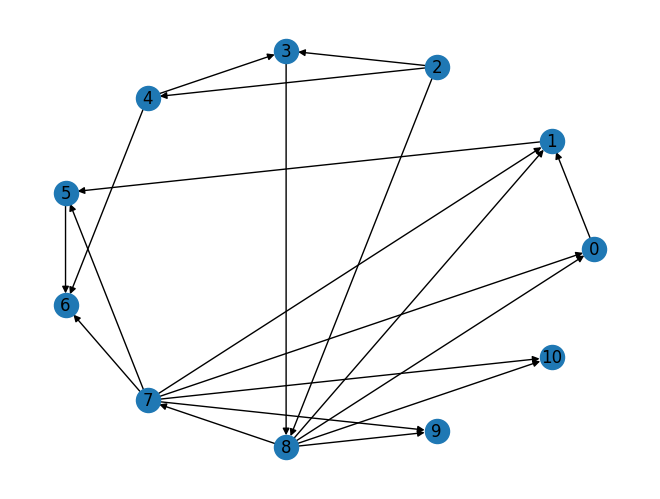

In [7]:
draw_ground_truth_from_dag(true_dag_sachs)

### Running

#### Test run multiple relations



In [15]:

true_dag_sachs = get_sachs_ground_truth_dag()
sachs_data, sachs_labels = load_dataset("sachs")

base_args_skeleton = {
      "data_name": "sachs",
      "real_data": sachs_data,
      "true_dag": true_dag_sachs,
      "observed": sachs_data.shape[1],
      "alpha": 0.01,
      "ci_test": "fisherz",
}

base_seed = 42
frac_forb = 0
frac_req = 0.3

base_args_skeleton["fraction_forbidden"] = frac_forb
base_args_skeleton["fraction_required"] = frac_req

# Run experiment
result_dict_42, details_dict_42 = run_experiment_mpdag_real(base_args_skeleton, base_seed, forward_pairs_idx)

100%|██████████| 46/46 [00:15<00:00,  2.92it/s]


In [16]:
import pandas as pd
import numpy as np

# 1. Define your relations in the same order they were generated
relations = [
    "Plcg -> PIP3", "Plcg -> PIP2", "Plcg -> PKC", "Plcg -> PKA", "Plcg -> Raf",
    "Plcg -> Mek", "Plcg -> Erk", "Plcg -> Akt", "Plcg -> P38", "Plcg -> Jnk",
    "PIP3 -> PIP2", "PIP3 -> PKC", "PIP3 -> PKA", "PIP3 -> Raf", "PIP3 -> Mek",
    "PIP3 -> Erk", "PIP3 -> Akt", "PIP3 -> P38", "PIP3 -> Jnk", "PIP2 -> PKC",
    "PIP2 -> PKA", "PIP2 -> Raf", "PIP2 -> Mek", "PIP2 -> Erk", "PIP2 -> Akt",
    "PIP2 -> P38", "PIP2 -> Jnk", "PKC -> PKA", "PKC -> Raf", "PKC -> Mek",
    "PKC -> Erk", "PKC -> Akt", "PKC -> P38", "PKC -> Jnk", "PKA -> Raf",
    "PKA -> Mek", "PKA -> Erk", "PKA -> Akt", "PKA -> P38", "PKA -> Jnk",
    "Raf -> Mek", "Raf -> Erk", "Raf -> Akt", "Mek -> Erk", "Mek -> Akt",
    "Erk -> Akt"
]

# 2. Build a list of records for the DataFrame
data = []
for i, rel in enumerate(relations):
    data.append({
        "Relation": rel,
        "Prec (With B)": details_dict_42['with_b']['precision'][i],
        "Rec (With B)": details_dict_42['with_b']['recall'][i],
        "F1 (With B)": details_dict_42['with_b']['f1'][i],
        "Prec (No B)": details_dict_42['without_b']['precision'][i],
        "Rec (No B)": details_dict_42['without_b']['recall'][i],
        "F1 (No B)": details_dict_42['without_b']['f1'][i],
    })

# 3. Create DataFrame
results_df = pd.DataFrame(data)

# Optional: Set Relation as index and format numbers for better readability
results_df.set_index("Relation", inplace=True)
pd.options.display.float_format = '{:,.3f}'.format

# 4. Filter for only "successful" relations (where With B > 0) to see what worked
successful_results = results_df[results_df["F1 (With B)"] > 0]

print("--- Full Results Table ---")
print(results_df)

print("\n--- Relations where 'With B' found a valid OSET ---")
print(successful_results)

--- Full Results Table ---
              Prec (With B)  Rec (With B)  F1 (With B)  Prec (No B)  \
Relation                                                              
Plcg -> PIP3          0.000         0.000        0.000        0.000   
Plcg -> PIP2          0.000         0.000        0.000        0.000   
Plcg -> PKC           0.000         0.000        0.000        0.000   
Plcg -> PKA           0.000         0.000        0.000        0.000   
Plcg -> Raf           0.000         0.000        0.000        0.000   
Plcg -> Mek           0.000         0.000        0.000        0.000   
Plcg -> Erk           0.000         0.000        0.000        0.000   
Plcg -> Akt           0.000         0.000        0.000        0.000   
Plcg -> P38           0.000         0.000        0.000        0.000   
Plcg -> Jnk           0.000         0.000        0.000        0.000   
PIP3 -> PIP2          0.000         0.000        0.000        0.000   
PIP3 -> PKC           0.000         0.000        0

In [17]:
successful_results

,Prec (With B),Rec (With B),F1 (With B),Prec (No B),Rec (No B),F1 (No B)
Relation,,,,,,
PIP3 -> PKA,0.333,1.000,0.500,0.000,0.000,0.000
PIP3 -> Jnk,1.000,1.000,1.000,0.000,0.000,0.000
PKA -> Jnk,1.000,1.000,1.000,0.000,0.000,0.000
Mek -> Akt,1.000,0.500,0.667,0.000,0.000,0.000
Erk -> Akt,0.333,0.500,0.400,0.000,0.000,0.000


#### Resolving issues on intervention distance

In [18]:
from src.real_data_applications.sachs import fit_oracle_weights


true_dag_sachs = get_sachs_ground_truth_dag()
sachs_data, sachs_labels = load_dataset("sachs")
oracle_dag = fit_oracle_weights(true_dag_sachs, sachs_data)

base_args_skeleton = {
      "data_name": "sachs",
      "real_data": sachs_data,
      "true_dag": oracle_dag,
      "observed": sachs_data.shape[1],
      "alpha": 0.01,
      "ci_test": "fisherz",
      "sampling_strategy": "global"
}

base_seed = 42
frac_forb = 0
frac_req = 0.3

base_args_skeleton["fraction_forbidden"] = frac_forb
base_args_skeleton["fraction_required"] = frac_req

# Run experiment
result_dict_42, details_dict_42 = run_experiment_mpdag_real(base_args_skeleton, base_seed, forward_pairs_idx)

100%|██████████| 46/46 [00:15<00:00,  3.01it/s]


In [23]:
sachs_data

array([[2.640e+01, 1.320e+01, 8.820e+00, ..., 1.700e+01, 4.490e+01,
        4.000e+01],
       [3.590e+01, 1.650e+01, 1.230e+01, ..., 3.370e+00, 1.650e+01,
        6.150e+01],
       [5.940e+01, 4.410e+01, 1.460e+01, ..., 1.140e+01, 3.190e+01,
        1.950e+01],
       ...,
       [2.810e+01, 4.490e+00, 1.880e+01, ..., 1.000e+00, 1.750e+00,
        2.000e+00],
       [3.460e+01, 7.100e+00, 5.730e+00, ..., 4.450e+01, 1.382e+03,
        2.440e+00],
       [3.050e+01, 1.010e+00, 7.300e+00, ..., 1.000e+00, 1.000e+00,
        1.650e+00]], shape=(7466, 11))

In [19]:
result_dict_42


{'precision_with_b': {'mean': np.float64(0.07971014492753623),
  'std': np.float64(0.2523778951777971)},
 'recall_with_b': {'mean': np.float64(0.08695652173913043),
  'std': np.float64(0.26177379519113686)},
 'f1_with_b': {'mean': np.float64(0.07753623188405796),
  'std': np.float64(0.23673038005680622)},
 'int_dist_with_b': {'mean': np.float64(0.14850239090892653),
  'std': np.float64(0.16764488752355436)},
 'precision_without_b': {'mean': np.float64(0.0), 'std': np.float64(0.0)},
 'recall_without_b': {'mean': np.float64(0.0), 'std': np.float64(0.0)},
 'f1_without_b': {'mean': np.float64(0.0), 'std': np.float64(0.0)},
 'int_dist_without_b': {'mean': np.float64(0.16391037754916105),
  'std': np.float64(0.1702151143086128)}}

## Exp 3: application to DREAM4 datasets

In [ ]:
from src.real_data_applications.sachs import fit_oracle_weights


### Subset 1

In [47]:
goldstandard_path = "experiments/dream4/DREAM4_GoldStandard_InSilico_Size100_multifactorial_1.tsv"
dream4_net1_gs = pd.read_csv(
    goldstandard_path,
    sep='\t',
    header=None,
    names=['cause', 'outcome', 'direction']
)

dream4_net1_gs.head()

,cause,outcome,direction
0,G2,G91,1
1,G3,G90,1
2,G4,G18,1
3,G6,G52,1
4,G6,G55,1


In [48]:
dream4_net1_gs_filtered = dream4_net1_gs[dream4_net1_gs['direction'] == 1]

In [49]:
dream4_net1_gs_filtered

,cause,outcome,direction
0,G2,G91,1
1,G3,G90,1
2,G4,G18,1
3,G6,G52,1
4,G6,G55,1
...,...,...,...
171,G92,G97,1
172,G92,G99,1
173,G92,G100,1
174,G95,G38,1


In [38]:
import networkx as nx

def sanitize_to_dag(graph: nx.DiGraph) -> nx.DiGraph:
    """
    Iteratively finds and breaks cycles in a directed graph to guarantee a strict DAG.
    It does this by removing one edge from every cycle it finds.
    """
    # Create a copy so we don't mutate the original biological graph
    safe_dag = graph.copy()
    
    cycle_count = 0
    while True:
        try:
            # Look for a cycle
            cycle = nx.find_cycle(safe_dag)
            
            # cycle is a list of edges, e.g., [(5, 51), (51, 5)]
            # We break the cycle by removing the very first edge in the list
            edge_to_remove = cycle[0]
            safe_dag.remove_edge(*edge_to_remove)
            
            cycle_count += 1
            print(f"Broke cycle by removing edge: {edge_to_remove}")
            
        except nx.NetworkXNoCycle:
            # If no cycles are found, we successfully made a DAG!
            break
            
    print(f"Sanitization complete. Removed {cycle_count} edges to ensure acyclicity.")
    return safe_dag

In [39]:
import networkx as nx
import pandas as pd

# The order of nodes must perfectly match the columns of your multifactorial data.
# E.g., NODE_ORDER = list(multifactorial_data.columns)  # ['G1', 'G2', ..., 'G100']

def get_dream4_ground_truth_dag(gs_dataframe: pd.DataFrame, node_order: list) -> nx.DiGraph:
    """
    Constructs the ground truth DAG for the DREAM4 dataset.
    Nodes are integer indices corresponding to the order in node_order.
    """
    # 1. Create the reverse mapping (string name -> integer index)
    name_to_idx = {name: idx for idx, name in enumerate(node_order)}

    true_dag = nx.DiGraph()

    # 2. Add ALL nodes as integer indices (0 through len(node_order)-1)
    # This ensures disconnected genes still exist mathematically in your graph
    true_dag.add_nodes_from(range(len(node_order)))

    # 3. Extract true edges and map string names to integer indices
    edges_by_index = []
    
    # We assume your dataframe was loaded with columns: ['cause', 'outcome', 'edge']
    for _, row in gs_dataframe.iterrows():
        cause_name = row['cause']
        outcome_name = row['outcome']
        edge_exists = row['edge'] 
        
        # In DREAM4, the file lists non-existent edges as 0. We ONLY want the 1s.
        if edge_exists == 1:
            # Safety check to ensure the nodes exist in our multifactorial dataset
            if cause_name in name_to_idx and outcome_name in name_to_idx:
                u = name_to_idx[cause_name]
                v = name_to_idx[outcome_name]
                edges_by_index.append((u, v))

    # 4. Add the integer edges to the graph
    true_dag.add_edges_from(edges_by_index)

    return true_dag

# --- How to use it in your pipeline ---

# 1. Load your multifactorial data
multifactorial_df = pd.read_csv("experiments/dream4/insilico_size100_1_multifactorial.tsv", sep='\t')
NODE_ORDER = list(multifactorial_df.columns)

# 2. Load the DREAM4 Gold Standard and give it headers
dream4_gs = pd.read_csv("experiments/dream4/DREAM4_GoldStandard_InSilico_Size100_multifactorial_1.tsv", 
                        sep='\t', header=None, names=['cause', 'outcome', 'edge'])

# 3. Generate the true binary DAG
binary_dag = sanitize_to_dag(get_dream4_ground_truth_dag(dream4_gs, NODE_ORDER))

# 4. Fit the Oracle Weights to get your linear SEM
dream4_data_array = multifactorial_df.to_numpy()
oracle_dag = fit_oracle_weights(binary_dag, dream4_data_array)

Broke cycle by removing edge: (5, 51)
Broke cycle by removing edge: (5, 54)
Broke cycle by removing edge: (82, 54)
Broke cycle by removing edge: (7, 11)
Broke cycle by removing edge: (32, 33)
Broke cycle by removing edge: (32, 64)
Broke cycle by removing edge: (73, 94)
Sanitization complete. Removed 7 edges to ensure acyclicity.


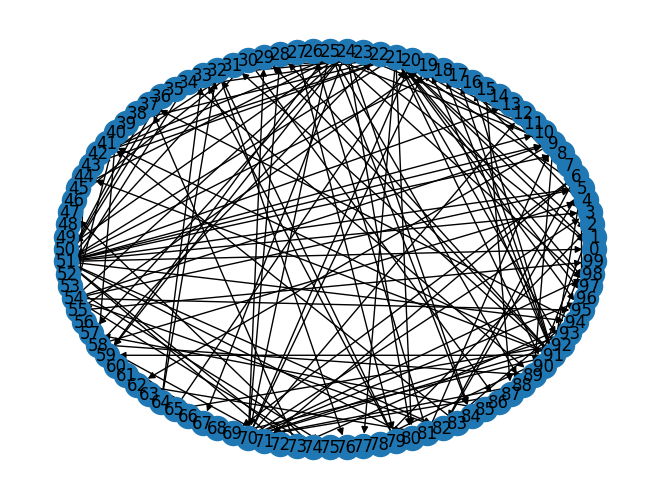

In [40]:
draw_ground_truth_from_dag(binary_dag)

In [41]:
import networkx as nx

# 1. Get all mathematically identifiable forward pairs (Ancestor -> Descendant)
# This uses the true_dag you generated earlier
forward_pairs_idx = []
for node in binary_dag.nodes():
    # nx.descendants finds all nodes downstream (direct and indirect)
    for descendant in nx.descendants(binary_dag, node):
        forward_pairs_idx.append([node, descendant])

In [42]:
len(forward_pairs_idx)

329

In [47]:

base_args_skeleton = {
      "data_name": "dream5_net2",
      "real_data": dream4_data_array,
      "true_dag": oracle_dag,
      "observed": dream4_data_array.shape[1],
      "alpha": 0.01,
      "ci_test": "fisherz",
      "sampling_strategy": "local"
}

base_seed = 42
frac_forb = 0
frac_req = 0.3

base_args_skeleton["fraction_forbidden"] = frac_forb
base_args_skeleton["fraction_required"] = frac_req

# Run experiment
result_dict_dream4, details_dict_dream4 = run_experiment_mpdag_real(base_args_skeleton, base_seed, forward_pairs_idx)

100%|██████████| 329/329 [00:32<00:00, 10.03it/s]


In [48]:
result_dict_dream4

{'precision_with_b': {'mean': np.float64(0.09387031408308004),
  'std': np.float64(0.27975193225488254)},
 'recall_with_b': {'mean': np.float64(0.07836879432624112),
  'std': np.float64(0.24300898653515723)},
 'f1_with_b': {'mean': np.float64(0.08111159357359965),
  'std': np.float64(0.24541317817656044)},
 'int_dist_with_b': {'mean': np.float64(0.04636611503864842),
  'std': np.float64(0.10196098572254689)},
 'precision_without_b': {'mean': np.float64(0.019756838905775075),
  'std': np.float64(0.13640611350952508)},
 'recall_without_b': {'mean': np.float64(0.016717325227963525),
  'std': np.float64(0.12368524017038852)},
 'f1_without_b': {'mean': np.float64(0.016616008105369808),
  'std': np.float64(0.11918683790882459)},
 'int_dist_without_b': {'mean': np.float64(0.07428273691763701),
  'std': np.float64(0.1522187586389359)}}

### Generic pipeline

In [51]:


def run_experiment_dream4(subset_number, sampling_strategy="local", frac_req=0.3):

    # 1. Load your multifactorial data
    multifactorial_df = pd.read_csv(f"experiments/dream4/insilico_size100_{subset_number}_multifactorial.tsv", sep='\t')
    NODE_ORDER = list(multifactorial_df.columns)

    # 2. Load the DREAM4 Gold Standard and give it headers
    dream4_gs = pd.read_csv(f"experiments/dream4/DREAM4_GoldStandard_InSilico_Size100_multifactorial_{subset_number}.tsv", 
                            sep='\t', header=None, names=['cause', 'outcome', 'edge'])

    # 3. Generate the true binary DAG
    binary_dag = sanitize_to_dag(get_dream4_ground_truth_dag(dream4_gs, NODE_ORDER))

    # 4. Fit the Oracle Weights to get your linear SEM
    dream4_data_array = multifactorial_df.to_numpy()
    oracle_dag = fit_oracle_weights(binary_dag, dream4_data_array)

    forward_pairs_idx = []
    for node in binary_dag.nodes():
        # nx.descendants finds all nodes downstream (direct and indirect)
        for descendant in nx.descendants(binary_dag, node):
            forward_pairs_idx.append([node, descendant])


    base_args_skeleton = {
        "data_name": f"dream4_net{subset_number}",
        "real_data": dream4_data_array,
        "true_dag": oracle_dag,
        "observed": dream4_data_array.shape[1],
        "alpha": 0.01,
        "ci_test": "fisherz",
        "sampling_strategy": sampling_strategy
    }

    base_seed = 42
    frac_forb = 0

    base_args_skeleton["fraction_forbidden"] = frac_forb
    base_args_skeleton["fraction_required"] = frac_req

    # Run experiment
    result_dict_dream4, details_dict_dream4 = run_experiment_mpdag_real(base_args_skeleton, base_seed, forward_pairs_idx)
    return result_dict_dream4, details_dict_dream4

In [52]:
import os
import csv
import numpy as np

# 1. Define the file path and ensure the directory exists
output_file = "experiments/dream4/b-load_results.csv"
os.makedirs(os.path.dirname(output_file), exist_ok=True)

# 2. Define the exact columns you want in your CSV
fieldnames = [
    "subset_number", "sampling_strategy", "frac_req",
    "precision_with_b_mean", "precision_with_b_std",
    "recall_with_b_mean", "recall_with_b_std",
    "f1_with_b_mean", "f1_with_b_std",
    "int_dist_with_b_mean", "int_dist_with_b_std",
    "precision_without_b_mean", "precision_without_b_std",
    "recall_without_b_mean", "recall_without_b_std",
    "f1_without_b_mean", "f1_without_b_std",
    "int_dist_without_b_mean", "int_dist_without_b_std"
]

# 3. Create the file and write the header row (overwrites if it already exists)
with open(output_file, mode='w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()

# 4. Your loops
for subset_number in tqdm(range(1, 6), desc="DREAM4 Subsets"):
    print(f"Running experiment for DREAM4 subset {subset_number}...")

    for sampling_strategy in tqdm(["local", "global"], desc=f"Strategy (Subset {subset_number})", leave=False):
        print(f"  Sampling strategy: {sampling_strategy}")

        frac_reqs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
        for frac_req in tqdm(frac_reqs, desc=f"Frac Req ({sampling_strategy})", leave=False):
            print(f"    Fraction required: {frac_req}")

            # Run your experiment
            result_dict, details_dict = run_experiment_dream4(subset_number, sampling_strategy, frac_req)

            # --- FLATTEN AND SAVE THE RESULTS ---
            
            # Start by adding your experiment parameters
            row_data = {
                "subset_number": subset_number,
                "sampling_strategy": sampling_strategy,
                "frac_req": frac_req
            }

            # Loop through the nested result_dict and extract mean/std
            for metric, stats in result_dict.items():
                row_data[f"{metric}_mean"] = float(stats['mean']) # Cast to float to clean up np.float64
                row_data[f"{metric}_std"] = float(stats['std'])

            # Open the file in 'a' (append) mode and write the row
            with open(output_file, mode='a', newline='') as f:
                writer = csv.DictWriter(f, fieldnames=fieldnames)
                writer.writerow(row_data)

print(f"Experiment complete! Results saved to {output_file}")


DREAM4 Subsets:   0%|          | 0/5 [00:00<?, ?it/s]

Running experiment for DREAM4 subset 1...


  Sampling strategy: local


    Fraction required: 0.1
Broke cycle by removing edge: (5, 51)
Broke cycle by removing edge: (5, 54)
Broke cycle by removing edge: (82, 54)
Broke cycle by removing edge: (7, 11)
Broke cycle by removing edge: (32, 33)
Broke cycle by removing edge: (32, 64)
Broke cycle by removing edge: (73, 94)
Sanitization complete. Removed 7 edges to ensure acyclicity.
















































































































































































































































































































































































100%|██████████| 329/329 [00:30<00:00, 10.72it/s]



...

    Fraction required: 0.6
Broke cycle by removing edge: (58, 91)
Broke cycle by removing edge: (7, 19)
Broke cycle by removing edge: (68, 9)
Broke cycle by removing edge: (50, 68)
Broke cycle by removing edge: (50, 81)
Sanitization complete. Removed 5 edges to ensure acyclicity.


    Fraction required: 0.7
Broke cycle by removing edge: (58, 91)
Broke cycle by removing edge: (7, 19)
Broke cycle by removing edge: (68, 9)
Broke cycle by removing edge: (50, 68)
Broke cycle by removing edge: (50, 81)
Sanitization complete. Removed 5 edges to ensure acyclicity.


    Fraction required: 0.8
Broke cycle by removing edge: (58, 91)
Broke cycle by removing edge: (7, 19)
Broke cycle by removing edge: (68, 9)
Broke cycle by removing edge: (50, 68)
Broke cycle by removing edge: (50, 81)
Sanitization complete. Removed 5 edges to ensure acyclicity.


    Fraction required: 0.9
Broke cycle by removing edge: (58, 91)
Broke cycle by removing edge: (7, 19)
Broke cycle by removing edge: (68, 9)
Broke cycle by removing edge: (50, 68)
Broke cycle by removing edge: (50, 81)
Sanitization complete. Removed 5 edges to ensure acyclicity.


Experiment complete! Results saved to experiments/dream4/b-load_results.csv


## Exp 4: application to DREAM5 dataset

In [20]:
goldstandard_path = "experiments/dream5/net2/dream5_net2_goldstandard.tsv"
dream5_net2_gs = pd.read_csv(
    goldstandard_path,
    sep='\t',
    header=None,
    names=['cause', 'outcome', 'direction']
)

dream5_net2_gs.head()

,cause,outcome,direction
0,G91,G992,1
1,G91,G2106,1
2,G91,G1997,1
3,G91,G892,1
4,G91,G2327,1


In [25]:
tf_path = "experiments/dream5/net2/net2_transcription_factors.tsv"
tf_net2 = pd.read_csv(
    tf_path,
    sep='\t',
    header=None,
    names=['gene_name']
)

tf_net2.head()

,gene_name
0,G1
1,G2
2,G3
3,G4
4,G5


In [27]:
TF_ORDER = tf_net2.values.flatten().tolist()
TF_ORDER

['G1',
 'G2',
 'G3',
 'G4',
 'G5',
 'G6',
 'G7',
 'G8',
 'G9',
 'G10',
 'G11',
 'G12',
 'G13',
 'G14',
 'G15',
 'G16',
 'G17',
 'G18',
 'G19',
 'G20',
 'G21',
 'G22',
 'G23',
 'G24',
 'G25',
 'G26',
 'G27',
 'G28',
 'G29',
 'G30',
 'G31',
 'G32',
 'G33',
 'G34',
 'G35',
 'G36',
 'G37',
 'G38',
 'G39',
 'G40',
 'G41',
 'G42',
 'G43',
 'G44',
 'G45',
 'G46',
 'G47',
 'G48',
 'G49',
 'G50',
 'G51',
 'G52',
 'G53',
 'G54',
 'G55',
 'G56',
 'G57',
 'G58',
 'G59',
 'G60',
 'G61',
 'G62',
 'G63',
 'G64',
 'G65',
 'G66',
 'G67',
 'G68',
 'G69',
 'G70',
 'G71',
 'G72',
 'G73',
 'G74',
 'G75',
 'G76',
 'G77',
 'G78',
 'G79',
 'G80',
 'G81',
 'G82',
 'G83',
 'G84',
 'G85',
 'G86',
 'G87',
 'G88',
 'G89',
 'G90',
 'G91',
 'G92',
 'G93',
 'G94',
 'G95',
 'G96',
 'G97',
 'G98',
 'G99']

In [21]:
# Filter rows where both 'cause' and 'outcome' are within G1-G99
def is_valid_gene(g):
    if g.startswith('G'):
        try:
            num = int(g[1:])
            return 1 <= num <= 99
        except ValueError:
            return False
    return False

dream5_net2_gs = dream5_net2_gs[
    dream5_net2_gs['cause'].apply(is_valid_gene) &
    dream5_net2_gs['outcome'].apply(is_valid_gene)
]

In [22]:
dream5_net2_gs

,cause,outcome,direction
6,G91,G89,1
109,G58,G90,1
163,G63,G89,1
206,G61,G93,1
211,G61,G22,1
219,G61,G12,1
221,G61,G35,1
227,G61,G65,1
243,G61,G60,1
244,G61,G60,1


In [28]:
import networkx as nx
import pandas as pd

# You MUST define this list so it exactly matches the column order of your 
# filtered 99-column expression dataset! 
# (e.g., TF_ORDER = ['G1', 'G2', 'G3', ..., 'G99'])
# You can usually get this from: tf_order = list(filtered_expression_df.columns)

def get_dream5_tf_ground_truth_dag(gs_dataframe: pd.DataFrame, tf_order: list) -> nx.DiGraph:
    """
    Constructs the ground truth DAG for the DREAM5 dataset, restricted to a specific list of TFs.
    Nodes are integer indices corresponding to the order in tf_order.
    """
    # 1. Create the reverse mapping (name -> index)
    name_to_idx = {name: idx for idx, name in enumerate(tf_order)}

    true_dag = nx.DiGraph()

    # 2. Add ALL nodes as integer indices (0 through 98)
    # CRITICAL: This ensures disconnected TFs still exist in the math!
    true_dag.add_nodes_from(range(len(tf_order)))

    # 3. Extract edges and map string names to integer indices
    edges_by_index = []
    for _, row in gs_dataframe.iterrows():
        cause_name = row['cause']
        outcome_name = row['outcome']
        
        # Safety check: Only add the edge if BOTH nodes are in our 99 TF list
        if cause_name in name_to_idx and outcome_name in name_to_idx:
            u = name_to_idx[cause_name]
            v = name_to_idx[outcome_name]
            edges_by_index.append((u, v))

    # 4. Add the integer edges to the graph
    true_dag.add_edges_from(edges_by_index)

    return true_dag

# --- How to use it in your pipeline ---
# Assuming your DataFrame from the screenshot is called `dream5_net2_gs`
binary_dag = get_dream5_tf_ground_truth_dag(dream5_net2_gs, TF_ORDER)

# Now it is ready for the Oracle!
# oracle_dag = fit_oracle_weights(binary_dag, filtered_expression_data)

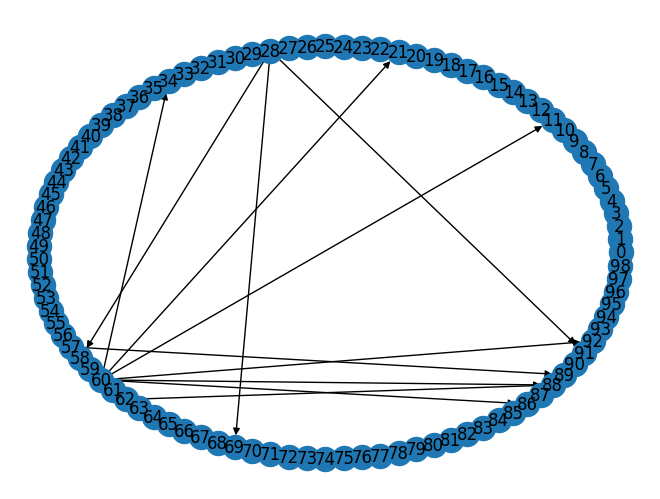

In [30]:
draw_ground_truth_from_dag(binary_dag)

In [32]:
data_path = "experiments/dream5/net2/net2_expression_data.tsv"
dream5_net2_data = pd.read_csv(
    data_path,
    sep='\t',
)

dream5_net2_data.head()

,G1,G2,G3,G4,G5,G6,G7,G8,G9,G10,...,G2801,G2802,G2803,G2804,G2805,G2806,G2807,G2808,G2809,G2810
0,11.4170,3.4503,8.7697,10.2360,10.682,6.7696,3.0706,5.9109,7.1084,2.9948,...,9.2903,6.7460,10.2340,8.5320,11.2000,6.7596,3.0931,6.1060,4.0310,6.3855
1,11.5230,3.2110,8.7012,10.3650,10.993,7.8541,2.9986,7.9172,8.8017,3.8001,...,9.8890,7.2070,9.9031,9.7466,11.6960,6.7143,4.1731,6.7891,6.0800,6.1492
2,10.8120,3.3019,7.8985,9.3980,10.531,6.2719,3.6029,7.3251,8.1590,3.7882,...,9.5365,7.5995,10.4710,8.9075,10.5090,6.0391,3.5458,6.6024,4.9454,5.7570
3,6.4412,3.2361,7.5263,10.2340,10.829,6.6492,4.0350,4.8044,5.5976,3.5752,...,8.4762,6.1738,9.8242,9.5663,9.3834,6.3967,5.2876,8.7908,5.1029,5.6708
4,11.5440,3.5901,7.4973,9.5897,10.427,7.4338,2.8464,6.5610,5.8620,3.4624,...,8.3140,5.7297,9.4874,8.9849,9.7157,6.7349,3.8045,6.3339,4.7634,5.7785


In [33]:
filtered_expression_data = dream5_net2_data[TF_ORDER]
filtered_expression_data.head()

,G1,G2,G3,G4,G5,G6,G7,G8,G9,G10,...,G90,G91,G92,G93,G94,G95,G96,G97,G98,G99
0,11.4170,3.4503,8.7697,10.2360,10.682,6.7696,3.0706,5.9109,7.1084,2.9948,...,9.7092,8.5531,9.6547,6.5268,7.8913,9.4457,8.2094,9.7127,5.1321,5.6159
1,11.5230,3.2110,8.7012,10.3650,10.993,7.8541,2.9986,7.9172,8.8017,3.8001,...,9.7899,9.3127,9.8486,7.1096,6.9530,8.4486,8.7360,9.8895,6.4767,6.8445
2,10.8120,3.3019,7.8985,9.3980,10.531,6.2719,3.6029,7.3251,8.1590,3.7882,...,8.8256,8.8163,10.4130,6.0717,6.9449,8.8717,8.5179,9.7063,4.5374,7.0866
3,6.4412,3.2361,7.5263,10.2340,10.829,6.6492,4.0350,4.8044,5.5976,3.5752,...,9.2271,9.0950,10.7390,7.6493,7.3431,7.1696,6.6855,9.8978,4.5375,6.5814
4,11.5440,3.5901,7.4973,9.5897,10.427,7.4338,2.8464,6.5610,5.8620,3.4624,...,10.3270,9.2676,9.1673,7.7764,5.2502,8.0879,7.1659,9.4732,4.4294,5.3487


In [34]:
filtered_expression_data.shape

(160, 99)

In [36]:
# Now it is ready for the Oracle!
oracle_dag_dream5 = fit_oracle_weights(binary_dag, filtered_expression_data.to_numpy())

In [38]:
import networkx as nx

# 1. Get all mathematically identifiable forward pairs (Ancestor -> Descendant)
# This uses the true_dag you generated earlier
forward_pairs_idx = []
for node in binary_dag.nodes():
    # nx.descendants finds all nodes downstream (direct and indirect)
    for descendant in nx.descendants(binary_dag, node):
        forward_pairs_idx.append([node, descendant])

In [39]:
forward_pairs_idx

[[28, 58],
 [28, 91],
 [28, 69],
 [57, 89],
 [60, 64],
 [60, 34],
 [60, 11],
 [60, 21],
 [60, 86],
 [60, 88],
 [60, 59],
 [60, 92],
 [62, 88],
 [90, 88]]

In [40]:
from src.real_data_applications.sachs import fit_oracle_weights



base_args_skeleton = {
      "data_name": "dream5_net2",
      "real_data": filtered_expression_data.to_numpy(),
      "true_dag": oracle_dag_dream5,
      "observed": filtered_expression_data.to_numpy().shape[1],
      "alpha": 0.01,
      "ci_test": "fisherz",
      "sampling_strategy": "local"
}

base_seed = 42
frac_forb = 0
frac_req = 0.3

base_args_skeleton["fraction_forbidden"] = frac_forb
base_args_skeleton["fraction_required"] = frac_req

# Run experiment
result_dict_dream5, details_dict_dream5 = run_experiment_mpdag_real(base_args_skeleton, base_seed, forward_pairs_idx)

100%|██████████| 14/14 [01:11<00:00,  5.08s/it]


In [41]:
result_dict_dream5

{'precision_with_b': {'mean': np.float64(0.0), 'std': np.float64(0.0)},
 'recall_with_b': {'mean': np.float64(0.0), 'std': np.float64(0.0)},
 'f1_with_b': {'mean': np.float64(0.0), 'std': np.float64(0.0)},
 'int_dist_with_b': {'mean': np.float64(0.1182483267104889),
  'std': np.float64(0.12761924677767486)},
 'precision_without_b': {'mean': np.float64(0.0), 'std': np.float64(0.0)},
 'recall_without_b': {'mean': np.float64(0.0), 'std': np.float64(0.0)},
 'f1_without_b': {'mean': np.float64(0.0), 'std': np.float64(0.0)},
 'int_dist_without_b': {'mean': np.float64(0.14801022838883449),
  'std': np.float64(0.10248319679015647)}}

In [42]:


def test_dream5(sampling_strategy, frac_req):
    base_args_skeleton = {
        "data_name": "dream5_net2",
        "real_data": filtered_expression_data.to_numpy(),
        "true_dag": oracle_dag_dream5,
        "observed": filtered_expression_data.to_numpy().shape[1],
        "alpha": 0.01,
        "ci_test": "fisherz",
        "sampling_strategy": sampling_strategy
    }

    base_seed = 42
    frac_forb = 0
    frac_req = frac_req

    base_args_skeleton["fraction_forbidden"] = frac_forb
    base_args_skeleton["fraction_required"] = frac_req

    # Run experiment
    result_dict_dream5, details_dict_dream5 = run_experiment_mpdag_real(base_args_skeleton, base_seed, forward_pairs_idx)
    return result_dict_dream5, details_dict_dream5

for sampling_strategy in tqdm(["local", "global"]):
    for frac_req in tqdm([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]):
        print(f"Testing sampling_strategy={sampling_strategy}, frac_req={frac_req}")
        result_dict, details_dict = test_dream5(sampling_strategy, frac_req)
        print(f"Results: {result_dict}\n")

  0%|          | 0/2 [00:00<?, ?it/s]

Testing sampling_strategy=local, frac_req=0.1

















100%|██████████| 14/14 [01:12<00:00,  5.18s/it]


Results: {'precision_with_b': {'mean': np.float64(0.0), 'std': np.float64(0.0)}, 'recall_with_b': {'mean': np.float64(0.0), 'std': np.float64(0.0)}, 'f1_with_b': {'mean': np.float64(0.0), 'std': np.float64(0.0)}, 'int_dist_with_b': {'mean': np.float64(0.12138934648755431), 'std': np.float64(0.09469497760526115)}, 'precision_without_b': {'mean': np.float64(0.0), 'std': np.float64(0.0)}, 'recall_without_b': {'mean': np.float64(0.0), 'std': np.float64(0.0)}, 'f1_without_b': {'mean': np.float64(0.0), 'std': np.float64(0.0)}, 'int_dist_without_b': {'mean': np.float64(0.14801022838883449), 'std': np.float64(0.10248319679015647)}}

Testing sampling_strategy=local, frac_req=0.2

















100%|██████████| 14/14 [01:14<00:00,  5.29s/it]


...

Results: {'precision_with_b': {'mean': np.float64(0.03015873015873016), 'std': np.float64(0.07399277473528042)}, 'recall_with_b': {'mean': np.float64(0.10714285714285714), 'std': np.float64(0.2789374884252377)}, 'f1_with_b': {'mean': np.float64(0.04638218923933209), 'std': np.float64(0.11456306850658947)}, 'int_dist_with_b': {'mean': np.float64(0.13222188565789758), 'std': np.float64(0.09706153634498679)}, 'precision_without_b': {'mean': np.float64(0.0), 'std': np.float64(0.0)}, 'recall_without_b': {'mean': np.float64(0.0), 'std': np.float64(0.0)}, 'f1_without_b': {'mean': np.float64(0.0), 'std': np.float64(0.0)}, 'int_dist_without_b': {'mean': np.float64(0.14801022838883449), 'std': np.float64(0.10248319679015647)}}

Testing sampling_strategy=global, frac_req=0.8

















100%|██████████| 14/14 [01:16<00:00,  5.44s/it]


Results: {'precision_with_b': {'mean': np.float64(0.03015873015873016), 'std': np.float64(0.07399277473528042)}, 'recall_with_b': {'mean': np.float64(0.10714285714285714), 'std': np.float64(0.2789374884252377)}, 'f1_with_b': {'mean': np.float64(0.04638218923933209), 'std': np.float64(0.11456306850658947)}, 'int_dist_with_b': {'mean': np.float64(0.14456294186088833), 'std': np.float64(0.14195165826051656)}, 'precision_without_b': {'mean': np.float64(0.0), 'std': np.float64(0.0)}, 'recall_without_b': {'mean': np.float64(0.0), 'std': np.float64(0.0)}, 'f1_without_b': {'mean': np.float64(0.0), 'std': np.float64(0.0)}, 'int_dist_without_b': {'mean': np.float64(0.14801022838883449), 'std': np.float64(0.10248319679015647)}}

Testing sampling_strategy=global, frac_req=0.9

















100%|██████████| 2/2 [23:17<00:00, 698.65s/it]

Results: {'precision_with_b': {'mean': np.float64(0.03469387755102041), 'std': np.float64(0.08651231997643528)}, 'recall_with_b': {'mean': np.float64(0.10714285714285714), 'std': np.float64(0.2789374884252377)}, 'f1_with_b': {'mean': np.float64(0.052154195011337875), 'std': np.float64(0.13122572604290508)}, 'int_dist_with_b': {'mean': np.float64(0.1330935001237859), 'std': np.float64(0.13880718316256935)}, 'precision_without_b': {'mean': np.float64(0.0), 'std': np.float64(0.0)}, 'recall_without_b': {'mean': np.float64(0.0), 'std': np.float64(0.0)}, 'f1_without_b': {'mean': np.float64(0.0), 'std': np.float64(0.0)}, 'int_dist_without_b': {'mean': np.float64(0.14801022838883449), 'std': np.float64(0.10248319679015647)}}



## Sanity check: intervention distance  

In [13]:
from src.data_generation import generate_data

test_data = generate_data(
    seed=42,
    observed=10,
    exp_degree=2,
    max_degree=5,
    targets=2,
    identifiable=True,
    samples_num=1000
)

test_data

{'id': '59cec7589e83a98fba77fd9dacbab7fe',
 'data': array([[ -3.63505158,  -0.76873818,  -0.28772807, ...,   0.23230753,
          -1.07700266,  -6.05018624],
        [  2.16836079,   2.03662913,  -0.7726199 , ...,  -1.24312522,
           1.00160473,   6.60753714],
        [ -3.98724701,   3.75444912,   1.08136934, ...,   0.32662184,
           2.29600404,   6.75773971],
        ...,
        [ 10.16566457,  -1.88825344,   1.27332614, ...,   0.40004951,
          -0.42050792,  -3.50439493],
        [ -7.64049774,  -3.48041397,   0.55219452, ...,   0.15187561,
          -1.86603757, -16.27763329],
        [ -5.8377286 ,  -0.31617746,  -1.30292839, ...,  -0.55057531,
           0.1135047 ,   2.07603658]], shape=(1000, 10)),
 'targets': array([3, 5], dtype=int32),
 'true_dag': <networkx.classes.digraph.DiGraph at 0x285c6876410>,
 'cpt': <rpy2.rinterface_lib.sexp.NULLType object at 0x285bf302110> [0],
 'treatment': np.int32(5),
 'outcome': np.int32(3)}

In [15]:
nx.to_numpy_array(test_data["true_dag"])

array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  2.71625598],
       [ 0.94953259,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.55412626,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        , -2.52711836],
       [-2.37526756,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  2.74848828,
         0.        ,  0.        ,  0.        